# 02 — Frame Labeling

**Primary path (free):** Load the aggregated CSV produced by `aggregate_frames.sql` and inspect the frame distributions. No per-article data needed.

**Secondary path (spot-checking only):** If you ran the full raw extraction (`extract_genai_gov.sql`), load those rows and run the Python preprocessing pipeline to manually verify that the frame labels make sense.

Start with Part A. Only run Part B if you want to audit individual article examples.

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import load_agg, monthly_volume_agg, frame_shares_agg
from src.dictionaries import MILESTONES

sns.set_theme(style='whitegrid', palette='colorblind')

  2%|▏         | 58.7M/3.91G [15:15<16:40:19, 64.1kB/s]


---
## Part A — Aggregated path (primary)

Run `aggregate_frames.sql` in the BigQuery console, download the result as CSV, and save to `data/processed/monthly_frames.csv`.

In [2]:
import os
from pathlib import Path
from google.cloud import bigquery

AGG_PATH = Path('../data/processed/monthly_frames.csv')

if AGG_PATH.exists():
    print(f'CSV already exists at {AGG_PATH}, skipping query.')
else:
    PROJECT = os.environ.get('BIGQUERY_PROJECT', 'genai-gdelt')
    client = bigquery.Client(project=PROJECT)
    sql = Path('../queries/aggregate_frames.sql').read_text()
    print('Running aggregate_frames.sql ...')
    df_bq = client.query(sql).to_dataframe()
    AGG_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_bq.to_csv(AGG_PATH, index=False)
    print(f'Saved {len(df_bq)} rows -> {AGG_PATH}')

Running aggregate_frames.sql ...
Saved 44 rows -> ../data/processed/monthly_frames.csv


In [3]:
agg_df = load_agg(AGG_PATH)
print(f'Loaded {len(agg_df)} months, {agg_df["total_articles"].sum():,} total articles')
agg_df.head()

Loaded 44 months, 284,562 total articles


,month,total_articles,frame_innovation_opportunity,frame_risk_safety,frame_regulation_governance,frame_rights_privacy,frame_economic_competition_labour,frame_misinformation_integrity
0,2022-11,4123,54,70,60,14,24,14
1,2022-12,3437,68,105,52,29,26,1
2,2023-01,4286,97,96,83,23,55,8
3,2023-02,4550,97,65,114,19,117,6
4,2023-03,5524,129,129,148,52,91,25


In [4]:
# Monthly totals
vol = monthly_volume_agg(agg_df)
print('Date range:', vol.index[0], '→', vol.index[-1])
print('Peak month:', vol.idxmax(), '—', vol.max(), 'articles')
vol.tail()

Date range: 2022-11 → 2026-06
Peak month: 2026-05 — 9270 articles


month
2026-02    6814
2026-03    7252
2026-04    8344
2026-05    9270
2026-06    5525
Freq: M, Name: count, dtype: int64

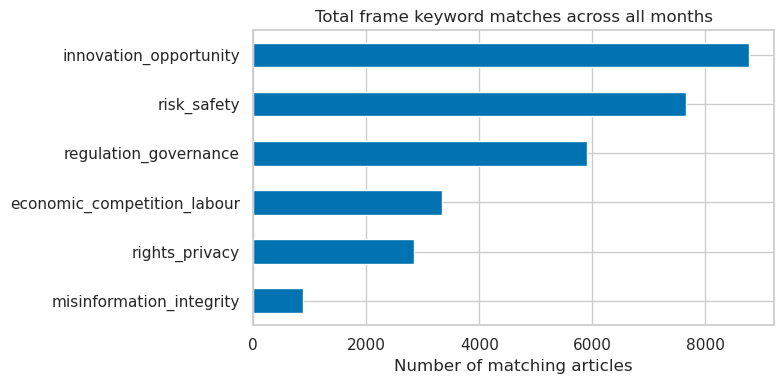


Frame totals:
innovation_opportunity         8775
risk_safety                    7650
regulation_governance          5910
economic_competition_labour    3334
rights_privacy                 2845
misinformation_integrity        888
dtype: int64


In [5]:
# Frame hit totals across all months
frame_cols = [c for c in agg_df.columns if c.startswith('frame_')]
frame_totals = agg_df[frame_cols].sum().rename(index=lambda x: x.replace('frame_', ''))

fig, ax = plt.subplots(figsize=(8, 4))
frame_totals.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Total frame keyword matches across all months')
ax.set_xlabel('Number of matching articles')
plt.tight_layout()
plt.show()

print('\nFrame totals:')
print(frame_totals.sort_values(ascending=False))

In [6]:
# Frame shares over time
shares = frame_shares_agg(agg_df)
shares.head()

,innovation_opportunity,risk_safety,regulation_governance,rights_privacy,economic_competition_labour,misinformation_integrity
month,,,,,,
2022-11,0.228814,0.296610,0.254237,0.059322,0.101695,0.059322
2022-12,0.241993,0.373665,0.185053,0.103203,0.092527,0.003559
2023-01,0.267956,0.265193,0.229282,0.063536,0.151934,0.022099
2023-02,0.232057,0.155502,0.272727,0.045455,0.279904,0.014354
2023-03,0.224739,0.224739,0.257840,0.090592,0.158537,0.043554


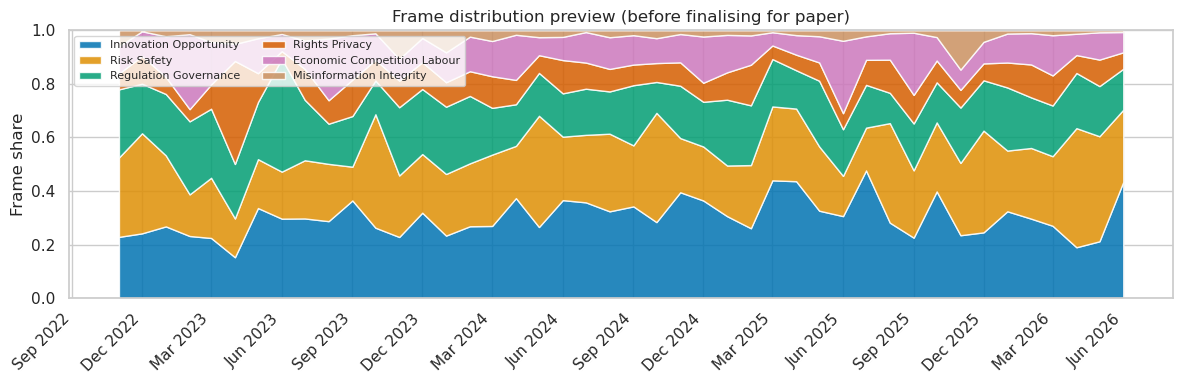

In [7]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
dates = shares.index.to_timestamp()
ax.stackplot(
    dates,
    [shares[col] for col in shares.columns],
    labels=[c.replace('_', ' ').title() for c in shares.columns],
    alpha=0.85,
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Frame share')
ax.set_ylim(0, 1)
ax.set_title('Frame distribution preview (before finalising for paper)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Sanity checks

Look for:
- Any months with suspiciously high or low totals (data gaps)
- Frame shares that seem implausible (e.g. one frame dominating at >80%)
- A visible uptick around Nov 2022 (ChatGPT launch) — if absent, revisit the GenAI filter

In [8]:
# Months with unusually low article counts (potential data gaps)
mean_vol = vol.mean()
low = vol[vol < mean_vol * 0.3]
if low.empty:
    print('No low-volume months detected.')
else:
    print('Potential data gaps:')
    print(low)

No low-volume months detected.


---
## Part B — Raw article spot-check (optional)

Only run this section if you want to audit individual articles by frame label.

**To get the corpus (~3.6 GB CSV):** either
- Run the dry-run cell below to confirm cost, then the BQ extraction cell, **or**
- Use the OneDrive download cell (faster if you have the sharing link).

In [1]:
# Dry-run: see bytes scanned before committing
import os
from google.cloud import bigquery

PROJECT = os.environ.get('BIGQUERY_PROJECT', 'genai-gdelt-499513')
client = bigquery.Client(project=PROJECT)
extract_sql = open('../queries/extract_genai_gov.sql').read()

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry = client.query(extract_sql, job_config=job_config)
gb = dry.total_bytes_processed / 1e9
tb = dry.total_bytes_processed / 1e12
print(f'extract_genai_gov.sql would scan {gb:.1f} GB  ({tb:.2f} TB)')
print(f'Estimated cost beyond free tier: ~${max(0, tb - 1) * 5:.2f}  (at $5/TB)')
print('Status:', 'SAFE (within 1 TB free tier)' if tb < 1 else f'CHARGEABLE — {tb:.2f} TB')

extract_genai_gov.sql would scan 871.3 GB  (0.87 TB)
Estimated cost beyond free tier: ~$0.00  (at $5/TB)
Status: SAFE (within 1 TB free tier)


In [4]:
# Full extraction — only run after confirming cost above
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')

if RAW_PATH.exists():
    print(f'Raw corpus already exists at {RAW_PATH}, skipping.')
else:
    print('Running extract_genai_gov.sql — this may take several minutes ...')
    df_raw = client.query(extract_sql).to_dataframe()
    RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw):,} rows -> {RAW_PATH}')

Running extract_genai_gov.sql — this may take several minutes ...
Saved 888,018 rows -> ../data/raw/gdelt_genai_gov.csv


In [3]:
# --- Alternative: download pre-extracted corpus from Google Drive ---
# 1. Upload gdelt_genai_gov.csv to personal Google Drive
# 2. Right-click → Share → 'Anyone with the link' → Copy link
# 3. Paste the file ID below (the part between /d/ and /view in the URL)
# pip install gdown  (if not already installed)
import gdown
from pathlib import Path

GDRIVE_FILE_ID = "1q2wkv877hodP7gwJTGzrcsXMw7RDthRU"  # ← e.g. '1aBcDeFgHiJkLmNoPqRsTuVwXyZ'
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')

if RAW_PATH.exists():
    print(f'Already exists: {RAW_PATH}  ({RAW_PATH.stat().st_size / 1e9:.1f} GB)')
else:
    RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
    gdown.download(url, str(RAW_PATH), quiet=False)

Already exists: ../data/raw/gdelt_genai_gov.csv  (3.9 GB)


In [7]:
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')
if not RAW_PATH.exists():
    print('Raw corpus not found — skip this section.')
else:
    from src.preprocessing import load_raw, run_pipeline
    from src.dictionaries import FRAME_DICTS

    raw_df = load_raw(RAW_PATH)
    df = run_pipeline(raw_df)
    print(f'Loaded {len(df):,} articles after dedup')

Loaded 887,254 articles after dedup


In [8]:
# Save preprocessed corpus for Figure 4 (regional comparison)
INTERIM_PATH = Path('../data/interim/gdelt_preprocessed.parquet')
if 'df' in dir() and not INTERIM_PATH.exists():
    INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(INTERIM_PATH, index=False)
    print(f'Saved {len(df):,} rows -> {INTERIM_PATH}')
elif INTERIM_PATH.exists():
    print(f'Already exists: {INTERIM_PATH}  ({INTERIM_PATH.stat().st_size / 1e6:.0f} MB)')
else:
    print('df not available — run the pipeline cell above first.')

Saved 887,254 rows -> ../data/interim/gdelt_preprocessed.parquet


In [6]:
# Sample 3 articles per dominant frame to verify labels
if 'df' in dir() and 'dominant_frame' in df.columns:
    SPOT_COLS = ['DATE', 'SourceCommonName', 'dominant_frame', 'Quotations']
    for frame_name in FRAME_DICTS:
        n_frame = (df['dominant_frame'] == frame_name).sum()
        if n_frame == 0:
            continue
        sample = df[df['dominant_frame'] == frame_name][SPOT_COLS].sample(
            min(3, n_frame), random_state=42
        )
        print(f'\n=== {frame_name} (n={n_frame:,}) ===')
        for _, row in sample.iterrows():
            print(f'  [{row["DATE"]}] {row["SourceCommonName"]}')
            print(f'  {str(row["Quotations"])[:250]}')


=== innovation_opportunity (n=37,823) ===
  [2026-06-04 00:00:00] batonrougepost.com
  
  [2024-01-08 00:00:00] bisnow.com
  
  [2025-04-21 00:00:00] wlky.com
  912|83||provide an opportunity for both sides to review the progress in bilateral relations#4856|40||supersmart daughter of indian immigrants

=== risk_safety (n=47,686) ===
  [2024-01-11 00:00:00] indiatimes.com
  
  [2025-07-23 00:00:00] wctrib.com
  
  [2023-09-19 00:00:00] cleveland.com
  2565|28||whereas the reality trembles#11162|34||prelude to the afternoon of a faun#15931|25||a charlie brown christmas#16273|45||around the world with the cleveland orchestra#16413|46||out of this world with the cleveland orchestra

=== regulation_governance (n=76,807) ===
  [2024-07-06 00:00:00] ilfattoquotidiano.it
  
  [2023-07-23 00:00:00] weeklyblitz.net
  
  [2025-06-11 00:00:00] townandcountrymag.com
  

=== rights_privacy (n=11,349) ===
  [2023-12-05 00:00:00] hngn.com
  
  [2024-05-27 00:00:00] haz.de
  
  [2026-03-12 00:00:00] g